# Temporal Order Ablation Analysis

This notebook visualizes the results of the Temporal Order Ablation experiment. The experiment tests whether the Temporal BiLSTM's high performance relies on sequence ordering or just the feature proportions in the time window.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ablation_metrics = pd.read_csv('../results/milestone_4_1/tables/temporal_order_ablation.csv')
ablation_delta = pd.read_csv('../results/milestone_4_1/tables/temporal_order_ablation_delta.csv')
scenario_ablation = pd.read_csv('../results/milestone_4_1/tables/scenario_order_ablation.csv')

print("=== ABLATION METRICS ===")
display(ablation_metrics)

print("\n=== ABLATION METRICS DIFFERENCE (Ordered - Shuffled) ===")
display(ablation_delta)

print("\n=== SCENARIO-LEVEL PERFORMANCE ===")
display(scenario_ablation.pivot(index='scenario', columns='ordering', values=['accuracy', 'mean_predicted_prob']))

=== ABLATION METRICS ===


,experiment,ordering,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,fpr,fnr,training_time_sec,inference_time_ms
0,Ordered,Ordered,1.000000,1.000000,1.00,1.000000,1.000000,1.000000,1.000000,0.000000,0.00,62.137178,430.350065
1,Shuffled,Order-Shuffled,0.826667,0.766304,0.94,0.844311,0.942789,0.948018,0.713333,0.286667,0.06,85.921126,398.082256



=== ABLATION METRICS DIFFERENCE (Ordered - Shuffled) ===


,delta_accuracy,delta_precision,delta_recall,delta_f1,delta_roc_auc,delta_pr_auc,delta_specificity,delta_fpr,delta_fnr
0,0.173333,0.233696,0.06,0.155689,0.057211,0.051982,0.286667,-0.286667,-0.06



=== SCENARIO-LEVEL PERFORMANCE ===


accuracy          mean_predicted_prob          
ordering          Ordered Shuffled             Ordered  Shuffled
scenario                                                        
ATTACK_ONSET          1.0     0.82            0.999977  0.549047
ATTACK_RECOVERY       1.0     0.14            0.000057  0.548516
NORMAL                1.0     1.00            0.000031  0.000452
SUSTAINED_ATTACK      1.0     1.00            0.999969  0.999479

## Visualizing the Difference

The metrics show a significant drop in Accuracy (1.0 -> ~0.82) and an increase in False Positive Rate (Specificity drops to ~0.71). Let's view the visualization generated by the script.

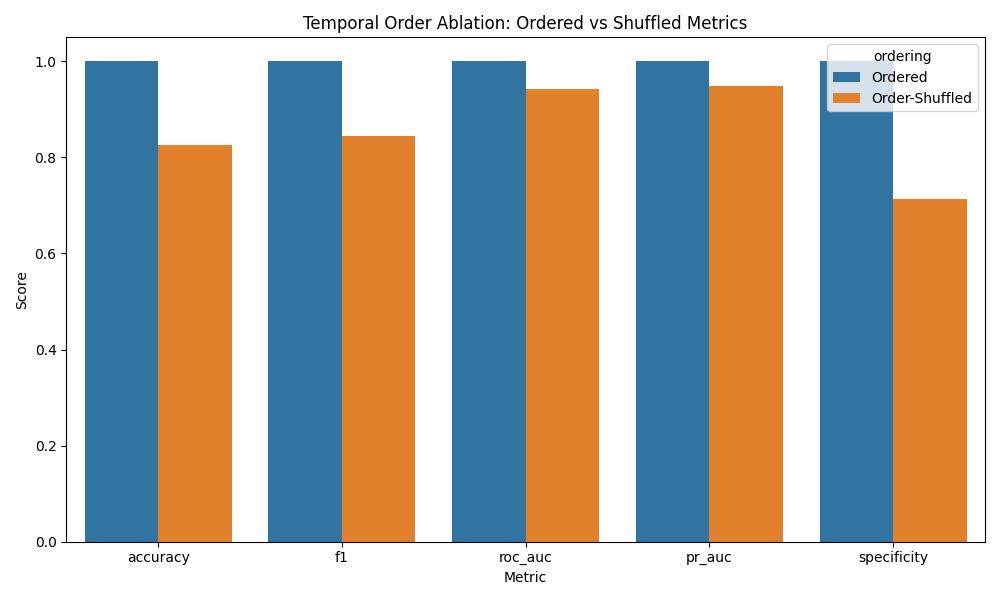

In [2]:
display(Image(filename='../results/milestone_4_1/figures/temporal_order_ablation_metrics.png'))

## Sequence Shuffling Example

This shows how the Attack Onset sequence looks before and after destroying the temporal order.

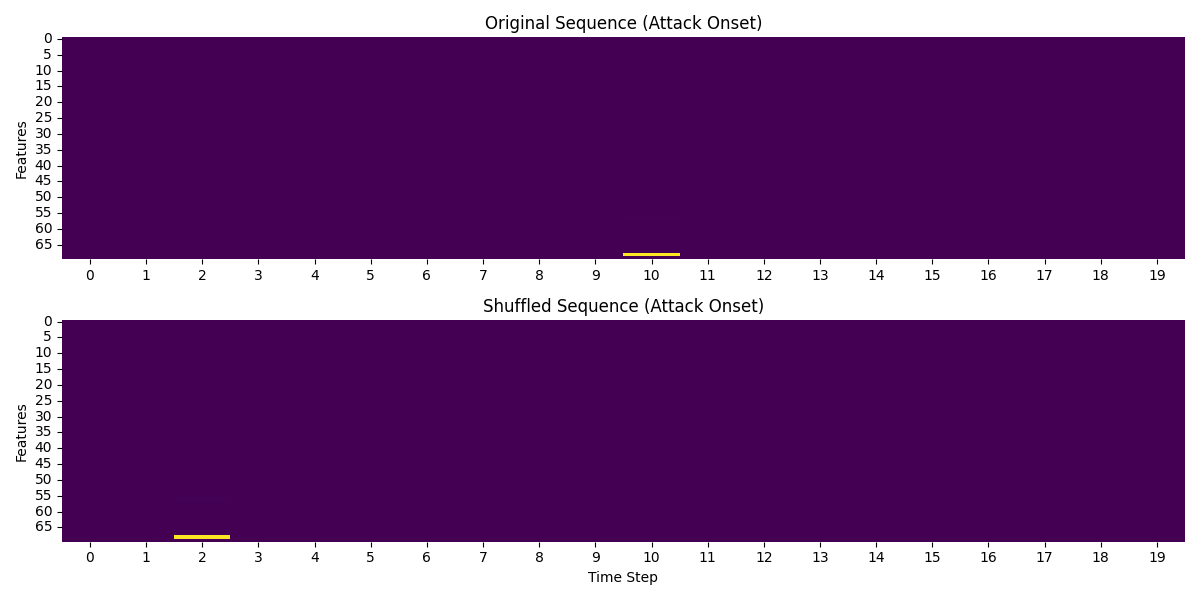

In [3]:
display(Image(filename='../results/milestone_4_1/figures/temporal_order_example.png'))

## Conclusion

The ablation results confirm that the Temporal BiLSTM uses the sequence ordering to effectively detect transition states (e.g., Attack Recovery dropped from 100% to 14% when shuffled). This validates the model's ability to capture temporal dynamics rather than simply memorizing static flow proportions.